In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(seq_len, d_model):
    """位置エンコーディングを計算する"""
    PE = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len).unsqueeze(1).float()
    div_term = torch.exp(
        torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
    )
    # 偶数次元にはsin、奇数次元にはcosを適用
    PE[:, 0::2] = torch.sin(position * div_term)
    PE[:, 1::2] = torch.cos(position * div_term)
    return PE

# 5単語・4次元で試す
PE = positional_encoding(5, 4)
print("位置エンコーディングの形:", PE.shape)
print("\n値:\n", PE.round(decimals=3))

位置エンコーディングの形: torch.Size([5, 4])

値:
 tensor([[ 0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8410,  0.5400,  0.0100,  1.0000],
        [ 0.9090, -0.4160,  0.0200,  1.0000],
        [ 0.1410, -0.9900,  0.0300,  1.0000],
        [-0.7570, -0.6540,  0.0400,  0.9990]])


In [11]:
# 各部分を分解して確認する
seq_len, d_model = 5, 4

# position：何番目の単語か（0〜4）
position = torch.arange(0, seq_len).unsqueeze(1).float()
print("position:\n", position)

# div_term：各次元の周波数
div_term = torch.exp(
    torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
)
print("\ndiv_term:", div_term)
print("div_termの形:", div_term.shape)

# 偶数次元（0, 2列目）にsin
print("\nsin部分:\n", torch.sin(position * div_term).round(decimals=3))

# 奇数次元（1, 3列目）にcos
print("\ncos部分:\n", torch.cos(position * div_term).round(decimals=3))  

position:
 tensor([[0.],
        [1.],
        [2.],
        [3.],
        [4.]])

div_term: tensor([1.0000, 0.0100])
div_termの形: torch.Size([2])

sin部分:
 tensor([[ 0.0000,  0.0000],
        [ 0.8410,  0.0100],
        [ 0.9090,  0.0200],
        [ 0.1410,  0.0300],
        [-0.7570,  0.0400]])

cos部分:
 tensor([[ 1.0000,  1.0000],
        [ 0.5400,  1.0000],
        [-0.4160,  1.0000],
        [-0.9900,  1.0000],
        [-0.6540,  0.9990]])


In [10]:
# div_termを分解して確認する
d_model = 4

# ① arange(0, d_model, 2) → 偶数インデックスだけ
step = torch.arange(0, d_model, 2).float()
print("step:", step)  # → [0, 2]

# ② -np.log(10000.0) / d_model
scale = -np.log(10000.0) / d_model
print("scale:", scale)  # → -2.302...

# ③ step * scale
exponent = step * scale
print("exponent:", exponent)  # → [0, -4.605...]

# ④ torch.exp(exponent)
div_term = torch.exp(exponent)
print("div_term:", div_term)  # → [1.0, 0.01]

step: tensor([0., 2.])
scale: -2.302585092994046
exponent: tensor([-0.0000, -4.6052])
div_term: tensor([1.0000, 0.0100])


In [12]:
# 単語ベクトル + 位置エンコーディング
X = torch.randn(5, 4)
PE = positional_encoding(5, 4)
X_with_pos = X + PE
print("位置情報込みの入力の形:", X_with_pos.shape)

位置情報込みの入力の形: torch.Size([5, 4])


In [14]:
# PyTorchのMultiheadAttentionを使う
mha = nn.MultiheadAttention(
    embed_dim=4,   # 単語ベクトルの次元数
    num_heads=2,   # ヘッド数（embed_dimの約数である必要がある）
    batch_first=True
)

# 入力
X = torch.randn(1, 5, 4)  # (バッチ, 系列長, 次元数)
print("入力の形:", X.shape)
print("入力:\n", X)
output, weights = mha(X, X, X)  # Q=K=V=X（Self-Attention）

print("出力の形:", output.shape)
print("Attentionの重みの形:", weights.shape)

入力の形: torch.Size([1, 5, 4])
入力:
 tensor([[[-0.8436, -0.8202, -0.1160,  0.1315],
         [ 1.5821,  0.1659,  0.9271, -0.3767],
         [-1.0889,  0.4845, -0.4982,  0.4098],
         [-1.6651,  1.9122, -0.7327,  0.0323],
         [ 0.9392,  0.2048, -0.3346,  0.8137]]])
出力の形: torch.Size([1, 5, 4])
Attentionの重みの形: torch.Size([1, 5, 5])


Attentionの重み（各単語がどこに注目しているか）:
tensor([[[0.2330, 0.1680, 0.2170, 0.2010, 0.1810],
         [0.1350, 0.2290, 0.1670, 0.2090, 0.2600],
         [0.2710, 0.1880, 0.1990, 0.1650, 0.1770],
         [0.3640, 0.1670, 0.1730, 0.1110, 0.1850],
         [0.1360, 0.2480, 0.1710, 0.2210, 0.2240]]])


/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31169 (\N{CJK UNIFIED IDEOGRAPH-79C1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12364 (\N{HIRAGANA LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29356 (\N{CJK UNIFIED IDEOGRAPH-72AC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:

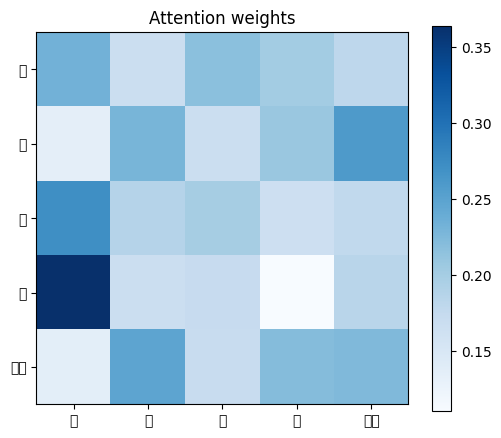

In [15]:
print("Attentionの重み（各単語がどこに注目しているか）:")
print(weights.detach().round(decimals=3))

plt.figure(figsize=(6, 5))
plt.imshow(weights[0].detach().numpy(), cmap='Blues')
plt.colorbar()
plt.xticks(range(5), ["私", "が", "犬", "を", "好き"])
plt.yticks(range(5), ["私", "が", "犬", "を", "好き"])
plt.title("Attention weights")
plt.show()